In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
sys.path.append('../../../src')
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, FilterEnum, ErrorEnum, NoiseTypeEnum
from scipy.optimize import minimize
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from noise_optimizers import EnKF_NoiseOptimizer
from numpy.linalg import norm

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
kitti_root_dir = '../../../data'
vo_root_dir = '../../../vo_estimates'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                vo_root_dir=vo_root_dir,
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/enkf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/enkf'

In [4]:
enkf_optimizer = EnKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
enkf_optimizer.compare(load_exported=True)

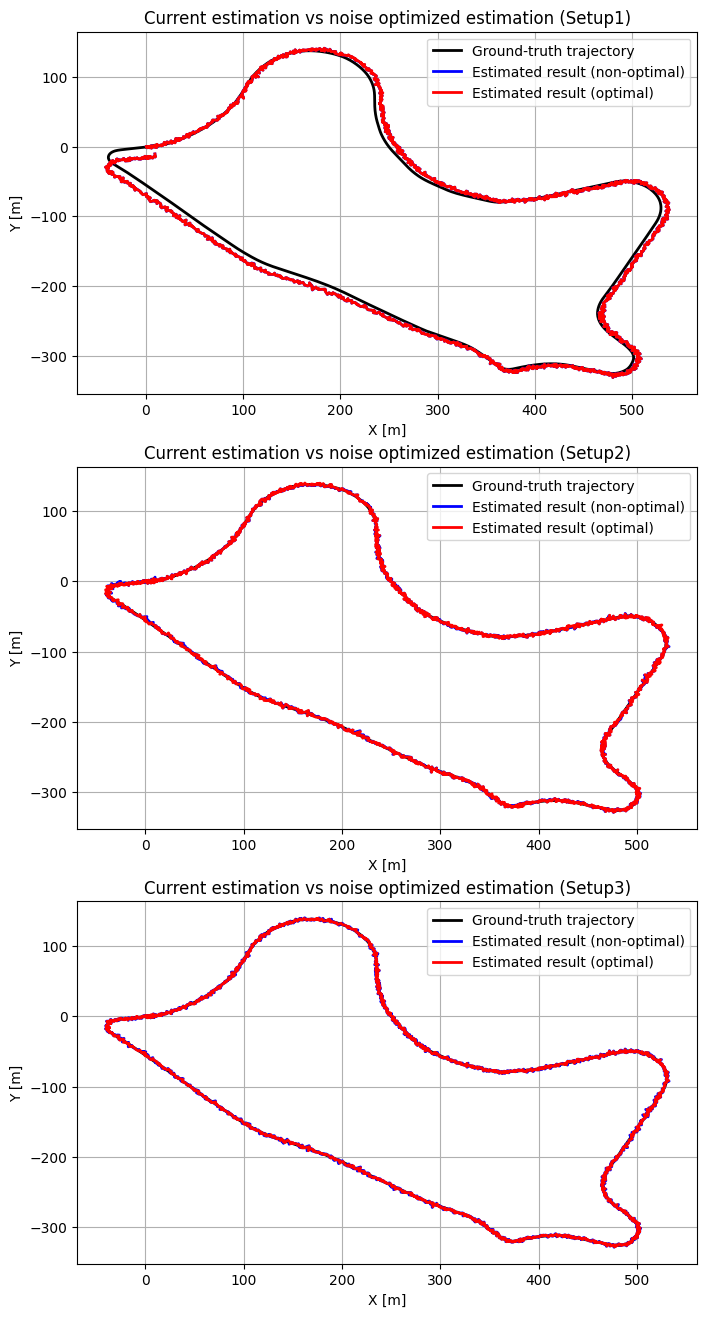

In [6]:
enkf_optimizer.visualize_results()

In [7]:
enkf_optimizer.error_df

Setups        Setup1(IMU+VO)                Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE     MAX                MAE   RMSE    MAX   
Non-optimized          4.053  5.621  17.910              1.078  1.356  5.274   
Optimized              4.055  5.614  17.743              1.056  1.327  5.547   
∆                      0.002 -0.007  -0.167             -0.022 -0.029  0.273   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       0.952  1.199  5.201  
Optimized           1.033  1.282  4.484  
∆                   0.081  0.083 -0.717

## Conclusion